# 🚀 ReDI School: The Optimization Challenge

### The Scenario
We have been given a dataset containing historical information about various cars, including features like the maker, body type, mileage, engine size, and fuel type. Most importantly, we know whether each of these cars experienced a severe breakdown (our target variable, `Label`). 

### The Goal
Our mission is to build a Machine Learning model that acts as an **early warning system**. We want to predict whether a new, unseen car is likely to break down (`Label = 1`) or run smoothly (`Label = 0`) based purely on its specifications. 

As always you can use either your local environment or the google colab for this challenge.

### Step 0: Setup and Helper Functions
Importing libraries and setting up our evaluation functions

In [493]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
#from imblearn import under_sampling, over_sampling

pd.set_option('display.max_columns', None)

In [494]:
!pip install imbalanced-learn

from imblearn.over_sampling import SMOTE


In [495]:
def evaluate_model(model, X_val, y_val, model_name):
    """
    Evaluates a trained classification model and generates a performance report.
    
    It runs the validation data through the model, compares the model's 
    predictions against the actual answers, and displays two things:
    1. A Classification Report: Shows Accuracy, Precision, Recall, and F1-Score.
    2. A Confusion Matrix: A heatmap showing exactly where the model made 
       mistakes (False Positives vs. False Negatives).
    
    Parameters:
    -----------
    model : object
        The trained machine learning model (e.g., RandomForestClassifier).
    X_val : pandas DataFrame
        The features (specifications) of our validation dataset.
    y_val : pandas Series
        The actual true labels (0 = no breakdown, 1 = breakdown) of our validation data.
    model_name : str
        A human-readable name for the model, used to create nice titles for our graphs.
        
    Returns:
    --------
    y_prob : numpy array
        The predicted probabilities that can be used for further analysis (like ROC curves).
    """
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]
    
    print(f"\n{'='*40}")
    print(f"EVALUATION: {model_name}")
    print(f"{'='*40}")
    print(classification_report(y_val, y_pred))
    
    plt.figure(figsize=(4, 3))
    sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    return y_prob


In [496]:
def plot_comparison_curves(y_val, prob_dict):
    """
    Plots ROC and Precision-Recall (PR) curves side-by-side for multiple models.
    
    This function acts as our "Ultimate Showdown Arena." Instead of looking at 
    text reports separately, we overlay the performance curves of our Baseline, 
    SMOTE, and Optimized models on the same graphs. This makes it instantly 
    visually obvious which model handles data the best.
    
    Parameters:
    -----------
    y_val : pandas Series
        The actual true labels of our validation data.
    prob_dict : dictionary
        A dictionary where the keys are the model names (Strings) and the values 
        are the predicted probabilities (numpy arrays) we saved earlier.
        Example: {'Baseline RF': [0.1, 0.9, 0.2...], 'SMOTE RF': [0.3, 0.8...]}
        
    Returns:
    --------
    None. It simply draws and displays the matplotlib/seaborn plots.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    for name, y_prob in prob_dict.items():
        fpr, tpr, _ = roc_curve(y_val, y_prob)
        roc_auc = auc(fpr, tpr)
        ax1.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')
        
        precision, recall, _ = precision_recall_curve(y_val, y_prob)
        pr_auc = average_precision_score(y_val, y_prob)
        ax2.plot(recall, precision, lw=2, label=f'{name} (AP = {pr_auc:.2f})')

    ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('ROC Curve Comparison')
    ax1.legend(loc="lower right")
    
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title('Precision-Recall Curve Comparison')
    ax2.legend(loc="lower left")
    
    plt.tight_layout()
    plt.show()

### Step 1: Load the Data

In [497]:
df = pd.read_csv("C:/Users/Ayobami Adeyemo/Downloads/artuvia/code files/code files/REDI_Project/labeled_data.csv")
df.head(10)
df.tail(20)

,ID,Maker,Genmodel,Genmodel_ID,Adv_year,Adv_month,Color,Reg_year,Bodytype,Runned_Miles,Engin_size,Gearbox,Fuel_type,Price,Seat_num,Door_num,issue,issue_id,Adv_day,breakdown_date,repair_complexity,repair_cost,repair_hours,repair_date,value,Label
37616,4363,Citroen,Grand C4 Picasso,18_24,2018,3,Brown,2012,MPV,72778,1.6L,Automatic,Diesel,6490,7,5,Brake Pads Worn,0,10,2018-03-10,2,83.245000,4.000000,2018-03-11,6164.561096,0
37617,31928,Ford,Focus,29_14,2018,8,Orange,2007,Hatchback,89500,2.5L,Manual,Petrol,4000,5,3,Alternator Failing,0,20,2018-08-20,1,120.000000,2.000000,2018-08-20,3791.219042,0
37618,7463,Citroen,Grand C4 Picasso,18_24,2018,3,Purple,2007,MPV,78000,1.6L,Automatic,Diesel,2475,7,5,Tyre Alignment,0,11,2018-03-11,2,20.247500,1.000000,2018-03-11,2346.693845,0
37619,48040,Dacia,Sandero Stepway,22_4,2018,7,Silver,2015,Hatchback,36501,1.5L,Manual,Diesel,7995,5,5,Electrical Issue,5,16,2018-07-16,1,67.995000,3.000000,2018-07-16,7596.829578,0
37620,18239,Dacia,Sandero Stepway,22_4,2018,6,Red,2016,Hatchback,89,1.5L,Manual,Diesel,8490,5,5,Radiator Leaking,0,16,2018-06-16,1,209.800000,2.000000,2018-06-16,8065.406477,0
37621,21022,Ford,Ka+,29_24,2018,8,Blue,2016,Hatchback,5000,1.2L,Manual,Petrol,8295,5,5,Transmission Issue,2,20,2018-08-20,1,-118.065000,3.000000,2018-08-20,7878.695678,0
37622,50715,Ford,Focus,29_14,2017,12,Gelb,2014,Hatchback,41758,1.6L,Manual,Diesel,7598,5,5,Brake Pads Worn,0,27,2017-12-27,1,43.799000,2.000000,2017-12-27,7223.686303,1
37623,11534,Ford,Kuga,29_25,2018,7,Silver,2009,SUV,70000,2.0L,Manual,Diesel,7000,5,5,Flat Tyres,0,15,2018-07-15,1,22.100000,1.000000,2018-07-15,6643.801974,0
37624,35968,Ford,S-Max,29_31,2018,8,White,2017,MPV,7244,2.0L,Automatic,Diesel,22000,7,5,Tyre Alignment,0,15,2018-08-15,1,40.363035,43.470264,2018-08-25,20893.242620,1
37625,35933,Fiat,500,28_2,2018,6,Green,2016,Hatchback,21450,1.2L,Manual,Petrol,6695,4,3,Brake Pads Worn,0,25,2018-06-25,1,43.347500,2.000000,2018-06-25,6360.431835,0


### Step 2: Exploratory Data Analysis (EDA)

 We want to find clues, understand relationships, and spot anomalies before we start building models

  In this step, we will
  1. **Inspect the data:** Check data types and look for missing values using `.info()`
  2. **Check the Balance:** Is our target variable (`Label`) imbalanced
  3. **Decide on which columns you want to use for the ML model and which columns you would discard:** Some columns may "leak" the results and spoil training, others require encoding before they will be passed to the model. 

In [498]:
#df_numeric = df.select_dtypes(include='number')
#sns.pairplot(df_numeric, hue='Label')

In [499]:
df.shape

(37636, 26)

In [500]:
df.duplicated().sum()

np.int64(0)

In [501]:
df.isnull().sum()

ID                   0
Maker                0
Genmodel             0
Genmodel_ID          0
Adv_year             0
Adv_month            0
Color                0
Reg_year             0
Bodytype             0
Runned_Miles         0
Engin_size           0
Gearbox              0
Fuel_type            0
Price                0
Seat_num             0
Door_num             0
issue                0
issue_id             0
Adv_day              0
breakdown_date       0
repair_complexity    0
repair_cost          0
repair_hours         0
repair_date          0
value                0
Label                0
dtype: int64

In [502]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37636 entries, 0 to 37635
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 37636 non-null  int64  
 1   Maker              37636 non-null  str    
 2   Genmodel           37636 non-null  str    
 3   Genmodel_ID        37636 non-null  str    
 4   Adv_year           37636 non-null  int64  
 5   Adv_month          37636 non-null  int64  
 6   Color              37636 non-null  str    
 7   Reg_year           37636 non-null  int64  
 8   Bodytype           37636 non-null  str    
 9   Runned_Miles       37636 non-null  int64  
 10  Engin_size         37636 non-null  str    
 11  Gearbox            37636 non-null  str    
 12  Fuel_type          37636 non-null  str    
 13  Price              37636 non-null  int64  
 14  Seat_num           37636 non-null  int64  
 15  Door_num           37636 non-null  int64  
 16  issue              37636 non-null

In [503]:
df.groupby('Label').size()

Label
0    33501
1     4135
dtype: int64

In [504]:
df['Label'].value_counts(normalize=True) * 100

Label
0    89.013179
1    10.986821
Name: proportion, dtype: float64

### According to above there is clearly an imbalance in the Label

In [505]:
df['breakdown_date'] = pd.to_datetime(df['breakdown_date'])
df['repair_date'] = pd.to_datetime(df['repair_date'])
df['downtime_days'] = (df['repair_date'] - df['breakdown_date']).dt.days
df.head()  

,ID,Maker,Genmodel,Genmodel_ID,Adv_year,Adv_month,Color,Reg_year,Bodytype,Runned_Miles,Engin_size,Gearbox,Fuel_type,Price,Seat_num,Door_num,issue,issue_id,Adv_day,breakdown_date,repair_complexity,repair_cost,repair_hours,repair_date,value,Label,downtime_days
0,11224,Chevrolet,Matiz,16_12,2018,8,Silver,2008,Hatchback,61200,1.0L,Manual,Petrol,699,5,5,Excessive Emissions,0,7,2018-08-07,1,20.6291,1.0,2018-08-07,664.756621,0,0
1,13673,Ford,Kuga,29_25,2018,5,White,2015,SUV,36579,2.0L,Manual,Diesel,12191,5,5,Radiator Leaking,0,9,2018-05-09,1,283.8200,2.0,2018-05-09,11581.844040,0,0
2,9528,Ford,Fiesta,29_13,2018,7,Red,2010,Hatchback,71000,1.25L,Manual,Petrol,2600,5,3,Engine Issue,3,14,2018-07-14,1,500.0000,12.0,2018-07-17,2469.094896,0,3
3,40424,DS,3,21_1,2018,3,Black,2017,Hatchback,6449,1.2L,Manual,Petrol,13458,5,3,Flat Tyres,0,25,2018-03-25,2,44.0374,2.0,2018-03-25,12785.925740,0,0
4,10711,Ford,S-Max,29_31,2018,5,White,2014,MPV,63751,2.0L,Automatic,still_Diesel_but_you_found_an_easteregg,11799,7,5,Windscreen Crack,0,14,2018-05-14,1,27.0794,1.0,2018-05-14,11203.608000,0,0


In [506]:
numeric_cols = df.select_dtypes(include='number')
df_negative = df[(numeric_cols < 0).any(axis=1)]
df_negative.head()

,ID,Maker,Genmodel,Genmodel_ID,Adv_year,Adv_month,Color,Reg_year,Bodytype,Runned_Miles,Engin_size,Gearbox,Fuel_type,Price,Seat_num,Door_num,issue,issue_id,Adv_day,breakdown_date,repair_complexity,repair_cost,repair_hours,repair_date,value,Label,downtime_days
22,14738,Ford,Focus,29_14,2018,5,Gelb,2004,Hatchback,56000,1.6L,Manual,Petrol,999,5,3,Transmission Issue,3,12,2018-05-12,1,-168.991000,8.0,2018-05-14,953.094805,1,2
23,19116,Ford,Ranger,29_30,2018,7,Grey,2004,Pickup,85000,2.5L,Manual,Diesel,4499,4,4,Gear Box Issue,0,20,2018-07-20,1,-485.356467,2.0,2018-07-20,4277.213679,1,0
26,40349,Dacia,Sandero Stepway,22_4,2018,7,White,2016,Hatchback,22000,0.9L,Manual,Petrol,6750,5,5,Starter Motor Issue,0,26,2018-07-26,1,-127.500000,3.0,2018-07-26,6418.919150,0,0
35,2478,Fiat,500,28_2,2018,5,Gelb,2013,Hatchback,19704,1.2L,Manual,Petrol,4995,4,3,Tyre Alignment,0,24,2018-05-24,1,-10.499500,0.5,2018-05-24,4743.259786,1,0
36,15958,Dacia,Duster,22_1,2018,3,Silver,2014,SUV,-9502,1.5L,Manual,Diesel,7011,5,5,Transmission Issue,3,6,2018-03-06,1,223.099000,8.0,2018-03-08,6667.253329,0,2


In [507]:
(numeric_cols < 0).sum()

ID                      0
Adv_year                0
Adv_month               0
Reg_year                0
Runned_Miles          134
Price                   0
Seat_num                0
Door_num                0
issue_id                0
Adv_day                 0
repair_complexity       0
repair_cost          3723
repair_hours            0
value                   0
Label                   0
downtime_days           0
dtype: int64

In [508]:
df.drop(df_negative.index, inplace=True)

In [509]:
df['yrs_exist'] =  df['breakdown_date'].dt.year - df['Reg_year']
df.head()

,ID,Maker,Genmodel,Genmodel_ID,Adv_year,Adv_month,Color,Reg_year,Bodytype,Runned_Miles,Engin_size,Gearbox,Fuel_type,Price,Seat_num,Door_num,issue,issue_id,Adv_day,breakdown_date,repair_complexity,repair_cost,repair_hours,repair_date,value,Label,downtime_days,yrs_exist
0,11224,Chevrolet,Matiz,16_12,2018,8,Silver,2008,Hatchback,61200,1.0L,Manual,Petrol,699,5,5,Excessive Emissions,0,7,2018-08-07,1,20.6291,1.0,2018-08-07,664.756621,0,0,10
1,13673,Ford,Kuga,29_25,2018,5,White,2015,SUV,36579,2.0L,Manual,Diesel,12191,5,5,Radiator Leaking,0,9,2018-05-09,1,283.8200,2.0,2018-05-09,11581.844040,0,0,3
2,9528,Ford,Fiesta,29_13,2018,7,Red,2010,Hatchback,71000,1.25L,Manual,Petrol,2600,5,3,Engine Issue,3,14,2018-07-14,1,500.0000,12.0,2018-07-17,2469.094896,0,3,8
3,40424,DS,3,21_1,2018,3,Black,2017,Hatchback,6449,1.2L,Manual,Petrol,13458,5,3,Flat Tyres,0,25,2018-03-25,2,44.0374,2.0,2018-03-25,12785.925740,0,0,1
4,10711,Ford,S-Max,29_31,2018,5,White,2014,MPV,63751,2.0L,Automatic,still_Diesel_but_you_found_an_easteregg,11799,7,5,Windscreen Crack,0,14,2018-05-14,1,27.0794,1.0,2018-05-14,11203.608000,0,0,4


In [510]:
assert (df['Runned_Miles'] >= 0).all()
assert (df['repair_cost'] >= 0).all()

print("No negative values found.")

No negative values found.


In [511]:
df.shape[0]

33795

### Below are evaluation of each parameters with the label

In [512]:
# Gearbox distribution
# To keep
df['Gearbox'].value_counts()

Gearbox
Manual            27819
Automatic          5935
Hybrid               23
Semi-Automatic       18
Name: count, dtype: int64

In [513]:
df.groupby('Gearbox')['Label'].value_counts()

Gearbox         Label
Automatic       0         5254
                1          681
Hybrid          1           16
                0            7
Manual          0        24854
                1         2965
Semi-Automatic  0           11
                1            7
Name: count, dtype: int64

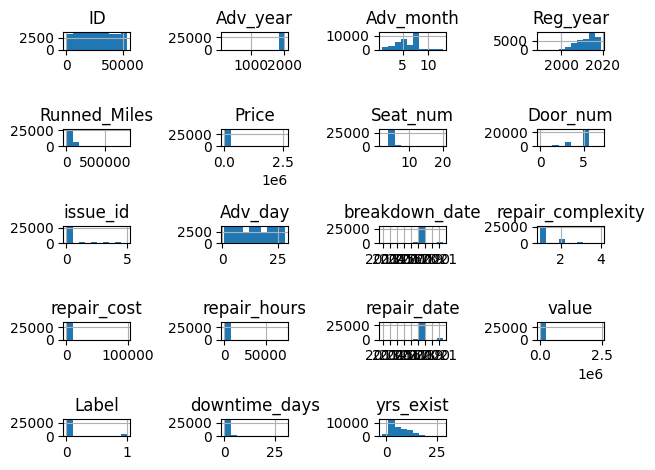

In [514]:
import matplotlib.pyplot as plt
df.hist()
plt.tight_layout()

In [515]:
df.isna().sum()

ID                   0
Maker                0
Genmodel             0
Genmodel_ID          0
Adv_year             0
Adv_month            0
Color                0
Reg_year             0
Bodytype             0
Runned_Miles         0
Engin_size           0
Gearbox              0
Fuel_type            0
Price                0
Seat_num             0
Door_num             0
issue                0
issue_id             0
Adv_day              0
breakdown_date       0
repair_complexity    0
repair_cost          0
repair_hours         0
repair_date          0
value                0
Label                0
downtime_days        0
yrs_exist            0
dtype: int64

In [516]:
# To drop
df['Engin_size'].value_counts()

Engin_size
1.6L      7926
2.0L      6060
1.2L      5112
1.4L      2924
1.0L      2391
1.5L      2159
1.3L      1171
2.2L       995
1.8L       990
1.25L      853
6.0L       470
0.9L       415
2.5L       348
1.1L       317
3.2L       258
4.0L       205
5.0L       166
1.9L       134
3.9L       110
3.0L        91
2.4L        79
4.3L        75
2.3L        75
4.5L        73
999.0L      59
2.8L        58
1.7L        41
6.2L        33
6.75L       32
6.3L        24
6.8L        21
3.6L        20
3.5L        20
0.8L        17
5.7L        11
5.5L         9
3.3L         9
0.66L        9
2.7L         8
6.5L         7
3.7L         3
6.1L         3
5.4L         2
3.8L         2
4.6L         2
5.2L         1
5.3L         1
6.7L         1
6.4L         1
7.0L         1
5.8L         1
4.2L         1
2.9L         1
Name: count, dtype: int64

In [517]:
# to keep
df.groupby('repair_complexity')['Label'].value_counts()

repair_complexity  Label
1                  0        22840
                   1         2980
2                  0         6025
                   1          501
3                  0         1195
                   1          170
4                  0           66
                   1           18
Name: count, dtype: int64

In [518]:
# To keep but how to encode? One-Hot Encoding
df['Fuel_type'].value_counts()

Fuel_type
Petrol                                     19216
Diesel                                     12929
still_Diesel_but_you_found_an_easteregg     1426
Hybrid  Petrol/Electric                      143
Petrol Hybrid                                 36
Hydrogen                                      27
Electric                                       5
Hybrid  Diesel/Electric                        5
Bi Fuel                                        4
Petrol Ethanol                                 2
Hybrid  Petrol/Electric Plug-in                1
Petrol Plug-in Hybrid                          1
Name: count, dtype: int64

In [519]:
df.groupby('Fuel_type')['Label'].value_counts()

Fuel_type                                Label
Bi Fuel                                  1            2
                                         0            2
Diesel                                   0        11646
                                         1         1283
Electric                                 1            3
                                         0            2
Hybrid  Diesel/Electric                  0            4
                                         1            1
Hybrid  Petrol/Electric                  0          134
                                         1            9
Hybrid  Petrol/Electric Plug-in          0            1
Hydrogen                                 1           19
                                         0            8
Petrol                                   0        17003
                                         1         2213
Petrol Ethanol                           0            2
Petrol Hybrid                            0           32
 

In [520]:
# To keep but how to encode? One-Hot Encoding
df['issue'].value_counts()

issue
Transmission Issue        2356
Flat Tyres                2331
Alternator Failing        2331
Brake Pads Worn           2288
Warning Light             2283
Engine Issue              2281
Steering Wheel Shaking    2270
Radiator Leaking          2269
Windscreen Crack          2241
Gear Box Issue            2237
Tyre Alignment            2234
Starter Motor Issue       2212
Sensor Malfunction        2189
Electrical Issue          2164
Excessive Emissions       2109
Name: count, dtype: int64

In [521]:
df.groupby('issue')['Label'].value_counts()

issue                   Label
Alternator Failing      0        2104
                        1         227
Brake Pads Worn         0        2039
                        1         249
Electrical Issue        0        1922
                        1         242
Engine Issue            0        2029
                        1         252
Excessive Emissions     0        1873
                        1         236
Flat Tyres              0        2068
                        1         263
Gear Box Issue          0        1994
                        1         243
Radiator Leaking        0        2009
                        1         260
Sensor Malfunction      0        1948
                        1         241
Starter Motor Issue     0        1952
                        1         260
Steering Wheel Shaking  0        2024
                        1         246
Transmission Issue      0        2120
                        1         236
Tyre Alignment          0        1995
                    

In [522]:
# To keep no encoding needed
df['issue_id'].value_counts()

issue_id
0    26994
2     1859
1     1760
3     1720
4     1055
5      407
Name: count, dtype: int64

In [523]:
df.groupby('issue_id')['Label'].value_counts()

issue_id  Label
0         0        24055
          1         2939
1         0         1575
          1          185
2         0         1680
          1          179
3         0         1550
          1          170
4         0          922
          1          133
5         0          344
          1           63
Name: count, dtype: int64

In [524]:
# to keep and encode
df['Maker'].value_counts()

Maker
Ford          16858
Citroen        5837
Fiat           4027
Honda          3189
Dacia          1106
Bentley         700
Chevrolet       466
DS              426
Ferrari         368
Abarth          251
Chrysler        231
Hyundai         161
Dodge            75
Daihatsu         61
Daewoo           10
Hummer            8
Great Wall        7
Cadillac          5
Caterham          3
GMC               2
Grinnall          1
Bugatti           1
Daimler           1
Corvette          1
Name: count, dtype: int64

In [525]:
df.groupby('Maker')['Label'].value_counts()

Maker       Label
Abarth      0          234
            1           17
Bentley     0          614
            1           86
Bugatti     0            1
Cadillac    0            4
            1            1
Caterham    0            2
            1            1
Chevrolet   0          428
            1           38
Chrysler    0          216
            1           15
Citroen     0         5392
            1          445
Corvette    0            1
DS          0          390
            1           36
Dacia       0          969
            1          137
Daewoo      0            9
            1            1
Daihatsu    0           57
            1            4
Daimler     1            1
Dodge       0           58
            1           17
Ferrari     0          304
            1           64
Fiat        0         3711
            1          316
Ford        0        14658
            1         2200
GMC         0            1
            1            1
Great Wall  0            6
          

In [526]:
# to keep and encode
df['Bodytype'].value_counts()

Bodytype
Hatchback          18450
MPV                 5704
SUV                 5161
Convertible         1167
Estate              1140
Coupe                856
Pickup               569
Saloon               449
Wood                 111
Combi Van             89
Car Derived Van       41
Minibus               38
Panel Van             17
Window Van             2
Tipper                 1
Name: count, dtype: int64

In [527]:
df.drop(columns=[])

,ID,Maker,Genmodel,Genmodel_ID,Adv_year,Adv_month,Color,Reg_year,Bodytype,Runned_Miles,Engin_size,Gearbox,Fuel_type,Price,Seat_num,Door_num,issue,issue_id,Adv_day,breakdown_date,repair_complexity,repair_cost,repair_hours,repair_date,value,Label,downtime_days,yrs_exist
0,11224,Chevrolet,Matiz,16_12,2018,8,Silver,2008,Hatchback,61200,1.0L,Manual,Petrol,699,5,5,Excessive Emissions,0,7,2018-08-07,1,20.629100,1.000000,2018-08-07,664.756621,0,0,10
1,13673,Ford,Kuga,29_25,2018,5,White,2015,SUV,36579,2.0L,Manual,Diesel,12191,5,5,Radiator Leaking,0,9,2018-05-09,1,283.820000,2.000000,2018-05-09,11581.844040,0,0,3
2,9528,Ford,Fiesta,29_13,2018,7,Red,2010,Hatchback,71000,1.25L,Manual,Petrol,2600,5,3,Engine Issue,3,14,2018-07-14,1,500.000000,12.000000,2018-07-17,2469.094896,0,3,8
3,40424,DS,3,21_1,2018,3,Black,2017,Hatchback,6449,1.2L,Manual,Petrol,13458,5,3,Flat Tyres,0,25,2018-03-25,2,44.037400,2.000000,2018-03-25,12785.925740,0,0,1
4,10711,Ford,S-Max,29_31,2018,5,White,2014,MPV,63751,2.0L,Automatic,still_Diesel_but_you_found_an_easteregg,11799,7,5,Windscreen Crack,0,14,2018-05-14,1,27.079400,1.000000,2018-05-14,11203.608000,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37629,11689,Ford,Focus,29_14,2018,3,Gelb,2016,Hatchback,45708,1.5L,Manual,Diesel,9611,5,5,Excessive Emissions,0,28,2018-03-28,1,98.820098,87.928753,2018-04-18,9123.324454,1,21,2
37630,39468,Citroen,Grand C4 Picasso,18_24,2018,3,Grey,2011,MPV,109000,1.6L,Manual,Diesel,4199,7,5,Gear Box Issue,0,12,2018-03-12,2,121.990000,4.000000,2018-03-13,3986.984460,0,1,7
37631,13233,DS,3,21_1,2018,3,Black,2017,Hatchback,10,1.2L,Automatic,Petrol,14000,5,3,Electrical Issue,1,24,2018-03-24,2,94.000000,4.000000,2018-03-25,13308.629850,0,1,1
37634,29733,Honda,CR-V,34_3,2018,5,Blue,2008,SUV,79000,2.0L,Automatic,Petrol,8495,5,5,Flat Tyres,0,12,2018-05-12,1,22.548500,1.000000,2018-05-12,8072.378880,0,0,10


In [528]:
df = df.drop(columns=['ID', 'Adv_year', 'Adv_month', 'Genmodel', 'Color', 'Reg_year', 'Genmodel_ID', 'Engin_size', 'breakdown_date', 'repair_date'])
# maker, bodytype, gearbox, issue
df

,Maker,Bodytype,Runned_Miles,Gearbox,Fuel_type,Price,Seat_num,Door_num,issue,issue_id,Adv_day,repair_complexity,repair_cost,repair_hours,value,Label,downtime_days,yrs_exist
0,Chevrolet,Hatchback,61200,Manual,Petrol,699,5,5,Excessive Emissions,0,7,1,20.629100,1.000000,664.756621,0,0,10
1,Ford,SUV,36579,Manual,Diesel,12191,5,5,Radiator Leaking,0,9,1,283.820000,2.000000,11581.844040,0,0,3
2,Ford,Hatchback,71000,Manual,Petrol,2600,5,3,Engine Issue,3,14,1,500.000000,12.000000,2469.094896,0,3,8
3,DS,Hatchback,6449,Manual,Petrol,13458,5,3,Flat Tyres,0,25,2,44.037400,2.000000,12785.925740,0,0,1
4,Ford,MPV,63751,Automatic,still_Diesel_but_you_found_an_easteregg,11799,7,5,Windscreen Crack,0,14,1,27.079400,1.000000,11203.608000,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37629,Ford,Hatchback,45708,Manual,Diesel,9611,5,5,Excessive Emissions,0,28,1,98.820098,87.928753,9123.324454,1,21,2
37630,Citroen,MPV,109000,Manual,Diesel,4199,7,5,Gear Box Issue,0,12,2,121.990000,4.000000,3986.984460,0,1,7
37631,DS,Hatchback,10,Automatic,Petrol,14000,5,3,Electrical Issue,1,24,2,94.000000,4.000000,13308.629850,0,1,1
37634,Honda,SUV,79000,Automatic,Petrol,8495,5,5,Flat Tyres,0,12,1,22.548500,1.000000,8072.378880,0,0,10


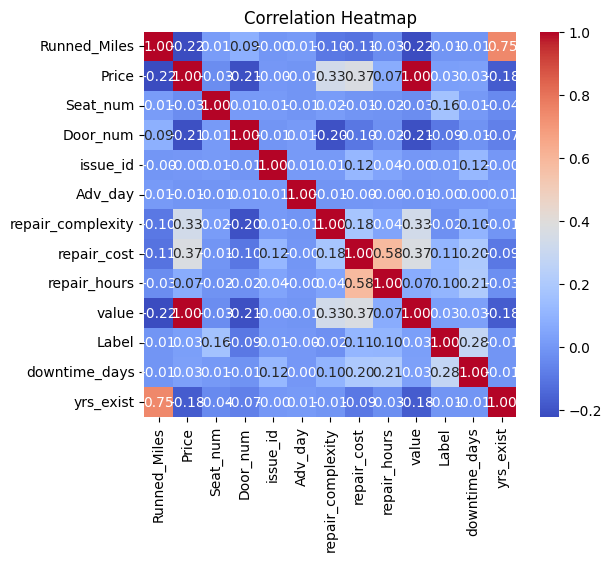

In [529]:
numeric_df = df.select_dtypes(include='number')

# Step 2: Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Step 3: Visualize with a Seaborn Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### Evaluating Unlabeled Data

In [530]:
unlabeled_df = pd.read_csv("C:/Users/Ayobami Adeyemo/Downloads/unlabeled_data.csv")
unlabeled_df.head()

,ID,Maker,Genmodel,Genmodel_ID,Adv_year,Adv_month,Color,Reg_year,Bodytype,Runned_Miles,Engin_size,Gearbox,Fuel_type,Price,Seat_num,Door_num,issue,issue_id,Adv_day,breakdown_date,repair_complexity,repair_cost,repair_hours,repair_date,value
0,29455,Ford,Kuga,29_25,2018,4,Green,2015,SUV,34000,2.0L,Automatic,Diesel,17290,5,5,Starter Motor Issue,0,15,2018-04-15,1,232.9000,3.0,2018-04-15,16423.784710
1,41446,Fiat,500,28_2,2018,8,White,2009,Hatchback,65000,1.2L,Manual,Petrol,3980,4,3,Warning Light,0,6,2018-08-06,1,219.8000,9.0,2018-08-08,3784.524678
2,42116,Fiat,500,28_2,2018,4,Black,2012,Hatchback,54491,1.2L,Manual,Petrol,4495,4,3,Flat Tyres,0,24,2018-04-24,1,21.3485,1.0,2018-04-24,4272.171246
3,32619,Citroen,DS4,21_3,2018,7,Silver,2011,Hatchback,98000,1.6L,Manual,still_Diesel_but_you_found_an_easteregg,4795,5,5,Starter Motor Issue,0,12,2018-07-12,2,167.9500,6.0,2018-07-13,4552.297593
4,51078,Abarth,595,2_4,2018,6,Red,2014,Hatchback,49583,1.4L,Automatic,Petrol,11000,4,3,Brake Pads Worn,0,20,2018-06-20,2,85.5000,4.0,2018-06-21,10447.615700


In [531]:
unlabeled_df.shape

(16130, 25)

In [532]:
unlabeled_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16130 entries, 0 to 16129
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 16130 non-null  int64  
 1   Maker              16130 non-null  str    
 2   Genmodel           16130 non-null  str    
 3   Genmodel_ID        16130 non-null  str    
 4   Adv_year           16130 non-null  int64  
 5   Adv_month          16130 non-null  int64  
 6   Color              16130 non-null  str    
 7   Reg_year           16130 non-null  int64  
 8   Bodytype           16130 non-null  str    
 9   Runned_Miles       16130 non-null  int64  
 10  Engin_size         16130 non-null  str    
 11  Gearbox            16130 non-null  str    
 12  Fuel_type          16130 non-null  str    
 13  Price              16130 non-null  int64  
 14  Seat_num           16130 non-null  int64  
 15  Door_num           16130 non-null  int64  
 16  issue              16130 non-null

In [533]:
unlabeled_df.describe()

,ID,Adv_year,Adv_month,Reg_year,Runned_Miles,Price,Seat_num,Door_num,issue_id,Adv_day,repair_complexity,repair_cost,repair_hours,value
count,16130.000000,16130.000000,16130.000000,16130.000000,16130.000000,1.613000e+04,16130.000000,16130.000000,16130.000000,16130.000000,16130.000000,16130.000000,16130.000000,1.613000e+04
mean,26918.335586,2006.910601,5.687601,2012.324613,48315.702294,1.222558e+04,5.085121,4.348977,0.497768,14.481401,1.283881,311.204484,66.822584,1.161424e+04
std,15487.095203,142.563826,2.079915,4.593881,40199.379087,3.562358e+04,1.546119,1.112513,1.131461,8.071887,0.550568,3053.690673,1568.566239,3.384234e+04
min,1.000000,202.000000,1.000000,1970.000000,-19585.000000,1.000000e+02,2.000000,0.000000,0.000000,1.000000,1.000000,-200464.259200,0.500000,9.984776e+01
25%,13595.500000,2018.000000,4.000000,2009.000000,15579.000000,3.571250e+03,5.000000,3.000000,0.000000,8.000000,1.000000,24.995000,1.000000,3.389750e+03
50%,26997.000000,2018.000000,5.000000,2013.000000,39555.000000,7.295000e+03,5.000000,5.000000,0.000000,14.000000,1.000000,83.798500,2.000000,6.927846e+03
75%,40298.750000,2018.000000,7.000000,2016.000000,74432.250000,1.189900e+04,5.000000,5.000000,0.000000,21.000000,1.000000,242.950000,6.000000,1.130483e+04
max,53760.000000,2021.000000,12.000000,2019.000000,880000.000000,2.200000e+06,20.000000,6.000000,5.000000,28.000000,4.000000,204334.464200,180985.493400,2.089990e+06


In [534]:
unlabeled_df.isnull().sum()

ID                   0
Maker                0
Genmodel             0
Genmodel_ID          0
Adv_year             0
Adv_month            0
Color                0
Reg_year             0
Bodytype             0
Runned_Miles         0
Engin_size           0
Gearbox              0
Fuel_type            0
Price                0
Seat_num             0
Door_num             0
issue                0
issue_id             0
Adv_day              0
breakdown_date       0
repair_complexity    0
repair_cost          0
repair_hours         0
repair_date          1
value                0
dtype: int64

In [535]:
unlabeled_df.dropna(inplace=True)

In [536]:
unlabeled_df.isnull().sum()

ID                   0
Maker                0
Genmodel             0
Genmodel_ID          0
Adv_year             0
Adv_month            0
Color                0
Reg_year             0
Bodytype             0
Runned_Miles         0
Engin_size           0
Gearbox              0
Fuel_type            0
Price                0
Seat_num             0
Door_num             0
issue                0
issue_id             0
Adv_day              0
breakdown_date       0
repair_complexity    0
repair_cost          0
repair_hours         0
repair_date          0
value                0
dtype: int64

In [537]:
unlabeled_numeric_cols = unlabeled_df.select_dtypes(include='number')
unlabeled_df_negative = unlabeled_df[(numeric_cols < 0).any(axis=1)]
unlabeled_df_negative.head()

C:\Users\Ayobami Adeyemo\AppData\Local\Temp\ipykernel_7984\1242502044.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  unlabeled_df_negative = unlabeled_df[(numeric_cols < 0).any(axis=1)]


,ID,Maker,Genmodel,Genmodel_ID,Adv_year,Adv_month,Color,Reg_year,Bodytype,Runned_Miles,Engin_size,Gearbox,Fuel_type,Price,Seat_num,Door_num,issue,issue_id,Adv_day,breakdown_date,repair_complexity,repair_cost,repair_hours,repair_date,value
22,31251,Citroen,DS3,21_1,2018,4,Grey,2011,Hatchback,48067,1.6L,Manual,Petrol,6000,5,3,Steering Wheel Shaking,0,16,2018-04-16,2,46.000,2.0,2018-04-16,5699.150709
23,5699,Ford,Mondeo,29_27,2018,6,Silver,2008,Estate,103000,2.0L,Manual,Diesel,2295,5,5,Electrical Issue,5,10,2018-06-10,1,62.295,3.0,2018-06-10,2175.933533
26,25705,Ford,Fiesta,29_13,2018,8,Grey,2014,Hatchback,78081,1.6L,Manual,still_Diesel_but_you_found_an_easteregg,6000,5,5,Steering Wheel Shaking,0,26,2018-08-26,1,-26.000,1.0,2018-08-26,5698.365050
35,24538,Citroen,C4,18_12,2018,7,Red,2011,Hatchback,39500,1.6L,Automatic,Diesel,5590,5,5,Windscreen Crack,0,17,2018-07-17,2,43.354,2.0,2018-07-17,5307.617190
36,4669,Bentley,Continental,10_5,2018,7,Grey,2015,Coupe,8668,6.0L,Automatic,Petrol,93950,4,2,Electrical Issue,3,3,2018-07-03,3,529.750,3.0,2018-07-03,89245.069980


In [538]:
(unlabeled_numeric_cols < 0).sum()

ID                      0
Adv_year                0
Adv_month               0
Reg_year                0
Runned_Miles           73
Price                   0
Seat_num                0
Door_num                0
issue_id                0
Adv_day                 0
repair_complexity       0
repair_cost          1612
repair_hours            0
value                   0
dtype: int64

In [539]:
unlabeled_df.drop(unlabeled_df_negative.index, inplace=True)

In [540]:
unlabeled_df.shape

(14502, 25)

In [541]:
unlabeled_df.head()

,ID,Maker,Genmodel,Genmodel_ID,Adv_year,Adv_month,Color,Reg_year,Bodytype,Runned_Miles,Engin_size,Gearbox,Fuel_type,Price,Seat_num,Door_num,issue,issue_id,Adv_day,breakdown_date,repair_complexity,repair_cost,repair_hours,repair_date,value
0,29455,Ford,Kuga,29_25,2018,4,Green,2015,SUV,34000,2.0L,Automatic,Diesel,17290,5,5,Starter Motor Issue,0,15,2018-04-15,1,232.9000,3.0,2018-04-15,16423.784710
1,41446,Fiat,500,28_2,2018,8,White,2009,Hatchback,65000,1.2L,Manual,Petrol,3980,4,3,Warning Light,0,6,2018-08-06,1,219.8000,9.0,2018-08-08,3784.524678
2,42116,Fiat,500,28_2,2018,4,Black,2012,Hatchback,54491,1.2L,Manual,Petrol,4495,4,3,Flat Tyres,0,24,2018-04-24,1,21.3485,1.0,2018-04-24,4272.171246
3,32619,Citroen,DS4,21_3,2018,7,Silver,2011,Hatchback,98000,1.6L,Manual,still_Diesel_but_you_found_an_easteregg,4795,5,5,Starter Motor Issue,0,12,2018-07-12,2,167.9500,6.0,2018-07-13,4552.297593
4,51078,Abarth,595,2_4,2018,6,Red,2014,Hatchback,49583,1.4L,Automatic,Petrol,11000,4,3,Brake Pads Worn,0,20,2018-06-20,2,85.5000,4.0,2018-06-21,10447.615700


In [542]:
unlabeled_df['breakdown_date'] = pd.to_datetime(unlabeled_df['breakdown_date'])
unlabeled_df['repair_date'] = pd.to_datetime(unlabeled_df['repair_date'])
unlabeled_df['downtime_days'] = (unlabeled_df['repair_date'] -unlabeled_df['breakdown_date']).dt.days
unlabeled_df.head()  

,ID,Maker,Genmodel,Genmodel_ID,Adv_year,Adv_month,Color,Reg_year,Bodytype,Runned_Miles,Engin_size,Gearbox,Fuel_type,Price,Seat_num,Door_num,issue,issue_id,Adv_day,breakdown_date,repair_complexity,repair_cost,repair_hours,repair_date,value,downtime_days
0,29455,Ford,Kuga,29_25,2018,4,Green,2015,SUV,34000,2.0L,Automatic,Diesel,17290,5,5,Starter Motor Issue,0,15,2018-04-15,1,232.9000,3.0,2018-04-15,16423.784710,0
1,41446,Fiat,500,28_2,2018,8,White,2009,Hatchback,65000,1.2L,Manual,Petrol,3980,4,3,Warning Light,0,6,2018-08-06,1,219.8000,9.0,2018-08-08,3784.524678,2
2,42116,Fiat,500,28_2,2018,4,Black,2012,Hatchback,54491,1.2L,Manual,Petrol,4495,4,3,Flat Tyres,0,24,2018-04-24,1,21.3485,1.0,2018-04-24,4272.171246,0
3,32619,Citroen,DS4,21_3,2018,7,Silver,2011,Hatchback,98000,1.6L,Manual,still_Diesel_but_you_found_an_easteregg,4795,5,5,Starter Motor Issue,0,12,2018-07-12,2,167.9500,6.0,2018-07-13,4552.297593,1
4,51078,Abarth,595,2_4,2018,6,Red,2014,Hatchback,49583,1.4L,Automatic,Petrol,11000,4,3,Brake Pads Worn,0,20,2018-06-20,2,85.5000,4.0,2018-06-21,10447.615700,1


In [543]:
unlabeled_df['yrs_exist'] =  unlabeled_df['breakdown_date'].dt.year - unlabeled_df['Reg_year']
unlabeled_df.head()

,ID,Maker,Genmodel,Genmodel_ID,Adv_year,Adv_month,Color,Reg_year,Bodytype,Runned_Miles,Engin_size,Gearbox,Fuel_type,Price,Seat_num,Door_num,issue,issue_id,Adv_day,breakdown_date,repair_complexity,repair_cost,repair_hours,repair_date,value,downtime_days,yrs_exist
0,29455,Ford,Kuga,29_25,2018,4,Green,2015,SUV,34000,2.0L,Automatic,Diesel,17290,5,5,Starter Motor Issue,0,15,2018-04-15,1,232.9000,3.0,2018-04-15,16423.784710,0,3
1,41446,Fiat,500,28_2,2018,8,White,2009,Hatchback,65000,1.2L,Manual,Petrol,3980,4,3,Warning Light,0,6,2018-08-06,1,219.8000,9.0,2018-08-08,3784.524678,2,9
2,42116,Fiat,500,28_2,2018,4,Black,2012,Hatchback,54491,1.2L,Manual,Petrol,4495,4,3,Flat Tyres,0,24,2018-04-24,1,21.3485,1.0,2018-04-24,4272.171246,0,6
3,32619,Citroen,DS4,21_3,2018,7,Silver,2011,Hatchback,98000,1.6L,Manual,still_Diesel_but_you_found_an_easteregg,4795,5,5,Starter Motor Issue,0,12,2018-07-12,2,167.9500,6.0,2018-07-13,4552.297593,1,7
4,51078,Abarth,595,2_4,2018,6,Red,2014,Hatchback,49583,1.4L,Automatic,Petrol,11000,4,3,Brake Pads Worn,0,20,2018-06-20,2,85.5000,4.0,2018-06-21,10447.615700,1,4


In [544]:
unlabeled_df = unlabeled_df.drop(columns=['ID', 'Adv_year', 'Adv_month', 'Genmodel', 'Color', 'Reg_year', 'Genmodel_ID', 'Engin_size', 'breakdown_date', 'repair_date'])
unlabeled_df.head()

,Maker,Bodytype,Runned_Miles,Gearbox,Fuel_type,Price,Seat_num,Door_num,issue,issue_id,Adv_day,repair_complexity,repair_cost,repair_hours,value,downtime_days,yrs_exist
0,Ford,SUV,34000,Automatic,Diesel,17290,5,5,Starter Motor Issue,0,15,1,232.9000,3.0,16423.784710,0,3
1,Fiat,Hatchback,65000,Manual,Petrol,3980,4,3,Warning Light,0,6,1,219.8000,9.0,3784.524678,2,9
2,Fiat,Hatchback,54491,Manual,Petrol,4495,4,3,Flat Tyres,0,24,1,21.3485,1.0,4272.171246,0,6
3,Citroen,Hatchback,98000,Manual,still_Diesel_but_you_found_an_easteregg,4795,5,5,Starter Motor Issue,0,12,2,167.9500,6.0,4552.297593,1,7
4,Abarth,Hatchback,49583,Automatic,Petrol,11000,4,3,Brake Pads Worn,0,20,2,85.5000,4.0,10447.615700,1,4


### Step 3: Data Cleaning & Preprocessing 

In this step, we will prepare our data for the model by doing the following:
1. **Fix Data Quality Issues:**
2. **Drop Leaky & Useless Columns:** Remove ID numbers and columns that "leak" the future predictions.
3. **Encode Categorical Columns:**

### Step 4: Train/Test Split
**Separate Features from Target:** Split our data into $X$ (the clues) and $y$ (the final answer/label).
**Hint** you have 2 csv files.

**Helper**. We can store the evaluation results in a dictionary so that we can further compare against other models

In [545]:
X = df.drop('Label', axis=1)
y = df['Label']

X = pd.get_dummies(X, drop_first=True)

In [546]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


### Smote: To address class imbalance, SMOTE was applied to the training data. The minority class was oversampled until both classes contained the same number of observations. This approach allowed the model to learn more representative patterns of vehicle breakdowns while preserving all majority-class observations. The results showed an improvement in Recall and F1-score, indicating better detection of breakdown cases.

In [547]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [548]:
print(y_train.value_counts())
print(y_train_smote.value_counts())

Label
0    24101
1     2935
Name: count, dtype: int64
Label
0    24101
1    24101
Name: count, dtype: int64


### Retrain the Model

In [549]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    random_state=42
)

model.fit(X_train_smote, y_train_smote)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [550]:
y_pred = model.predict(X_val)

In [551]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_val, y_pred))

Accuracy: 0.8976179908270454


In [552]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94      6025
           1       0.54      0.39      0.45       734

    accuracy                           0.90      6759
   macro avg       0.73      0.68      0.70      6759
weighted avg       0.89      0.90      0.89      6759



## Confusion Matrix to give the chart on Distributions in True Positive, False Positive, True Negative, False Negative

In [553]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)

print(cm)

[[5780  245]
 [ 447  287]]


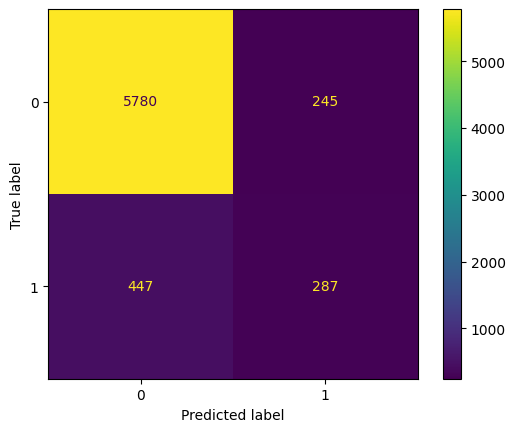

In [554]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(cm).plot()

plt.show()

## Comparing Before and After Smote

In [555]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score

model_no_smote = RandomForestClassifier(random_state=42)

model_no_smote.fit(X_train, y_train)

y_pred_no_smote = model_no_smote.predict(X_val)

acc_no = accuracy_score(y_val, y_pred_no_smote)
recall_no = recall_score(y_val, y_pred_no_smote)
precision_no = precision_score(y_val, y_pred_no_smote)
f1_no = f1_score(y_val, y_pred_no_smote)

print("WITHOUT SMOTE")
print("Accuracy:", acc_no)
print("Recall:", recall_no)
print("Precision:", precision_no)
print("F1:", f1_no)

WITHOUT SMOTE
Accuracy: 0.8986536469891996
Recall: 0.2547683923705722
Precision: 0.5753846153846154
F1: 0.35316336166194523


## Model 1: Random Forest

In [556]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred_no_smote))

              precision    recall  f1-score   support

           0       0.91      0.98      0.95      6025
           1       0.58      0.25      0.35       734

    accuracy                           0.90      6759
   macro avg       0.75      0.62      0.65      6759
weighted avg       0.88      0.90      0.88      6759



In [557]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_score

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

model_smote = RandomForestClassifier(random_state=42)

model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = model_smote.predict(X_val)

acc_smote = accuracy_score(y_val, y_pred_smote)
recall_smote = recall_score(y_val, y_pred_smote)
precision_smote = precision_score(y_val, y_pred_smote)
f1_smote = f1_score(y_val, y_pred_smote)

print("WITH SMOTE")
print("Accuracy:", acc_smote)
print("Recall:", recall_smote)
print("Precision:", precision_smote)
print("F1:", f1_smote)

WITH SMOTE
Accuracy: 0.8976179908270454
Recall: 0.391008174386921
Precision: 0.5394736842105263
F1: 0.45339652448657186


In [558]:
from sklearn.metrics import confusion_matrix

cm_no_smote = confusion_matrix(y_val, y_pred_no_smote)

print(cm_no_smote)

[[5887  138]
 [ 547  187]]


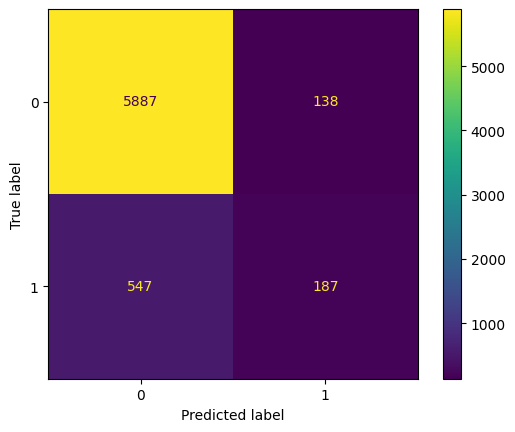

In [559]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(cm_no_smote).plot()

plt.show()

In [560]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred_smote))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94      6025
           1       0.54      0.39      0.45       734

    accuracy                           0.90      6759
   macro avg       0.73      0.68      0.70      6759
weighted avg       0.89      0.90      0.89      6759



In [561]:
from sklearn.metrics import accuracy_score, classification_report, f1_score
score = f1_score(y_val, y_pred_smote, average='macro')
print(f"F1 Score (Macro): {score:.2f}")

F1 Score (Macro): 0.70


In [562]:
import pandas as pd

comparison = pd.DataFrame({
    "Without SMOTE": [acc_no, recall_no, precision_no, f1_no],
    "With SMOTE": [acc_smote, recall_smote, precision_smote, f1_smote]
},
index=["Accuracy", "Recall", "Precision", "F1"])

print(comparison)

           Without SMOTE  With SMOTE
Accuracy        0.898654    0.897618
Recall          0.254768    0.391008
Precision       0.575385    0.539474
F1              0.353163    0.453397


## Computing ROC for Simple Random_Forest

In [563]:
from sklearn.metrics import roc_curve, auc

rf_prob = model_smote.predict_proba(X_val)[:,1]

rf_fpr, rf_tpr, _ = roc_curve(y_val, rf_prob)

rf_auc = auc(rf_fpr, rf_tpr)

print("RF AUC:", rf_auc)

RF AUC: 0.8507639603378294


## Model 2: Logistic Regression

In [564]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

lr.fit(X_train_smote, y_train_smote)

c:\Users\Ayobami Adeyemo\Downloads\artuvia\code files\code files\REDI_Project\.venv-2\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [565]:
y_pred_lr = lr.predict(X_val)

acc_lr = accuracy_score(y_val, y_pred_lr)
recall_lr = recall_score(y_val, y_pred_lr)
f1_lr = f1_score(y_val, y_pred_lr)

print("WITH SMOTE")
print("Accuracy:", acc_lr)
print("Recall:", recall_lr)
print("F1:", f1_lr)

WITH SMOTE
Accuracy: 0.7689007249593135
Recall: 0.5286103542234333
F1: 0.3319076133447391


In [566]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred_lr))

              precision    recall  f1-score   support

           0       0.93      0.80      0.86      6025
           1       0.24      0.53      0.33       734

    accuracy                           0.77      6759
   macro avg       0.59      0.66      0.60      6759
weighted avg       0.86      0.77      0.80      6759



In [567]:
from sklearn.metrics import accuracy_score, classification_report, f1_score
score = f1_score(y_val, y_pred_lr, average='macro')
print(f"F1 Score (Macro): {score:.2f}")

F1 Score (Macro): 0.60


## Computing ROC for Logistic Regression

In [568]:
lr_prob = lr.predict_proba(X_val)[:,1]

lr_fpr, lr_tpr, _ = roc_curve(y_val, lr_prob)

lr_auc = auc(lr_fpr, lr_tpr)

print("LR AUC:", lr_auc)

LR AUC: 0.7209680373557046


## Model 3: Gradient Boosting

In [569]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

gb.fit(X_train_smote, y_train_smote)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"init init: estimator or 'zero', default=NoneAn estimator object that is used to co

In [570]:
y_pred_gb = gb.predict(X_val)

acc_gb = accuracy_score(y_val, y_pred_gb)
recall_gb = recall_score(y_val, y_pred_gb)
f1_gb = f1_score(y_val, y_pred_gb)

print("WITH SMOTE")
print("Accuracy:", acc_gb)
print("Recall:", recall_gb)
print("F1:", f1_gb)

WITH SMOTE
Accuracy: 0.9002811066725847
Recall: 0.391008174386921
F1: 0.4599358974358974


In [571]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred_gb))

              precision    recall  f1-score   support

           0       0.93      0.96      0.95      6025
           1       0.56      0.39      0.46       734

    accuracy                           0.90      6759
   macro avg       0.74      0.68      0.70      6759
weighted avg       0.89      0.90      0.89      6759



In [572]:
from sklearn.metrics import accuracy_score, classification_report, f1_score
score = f1_score(y_val, y_pred_gb, average='macro')
print(f"F1 Score (Macro): {score:.2f}")

F1 Score (Macro): 0.70


#### Computing ROC for Gradient Boosting

In [573]:
gb_prob = gb.predict_proba(X_val)[:,1]

gb_fpr, gb_tpr, _ = roc_curve(y_val, gb_prob)

gb_auc = auc(gb_fpr, gb_tpr)

print("GB AUC:", gb_auc)

GB AUC: 0.8300785781315364


## Model 4: Decision Tree Classifier

In [574]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=10
)

dt.fit(X_train_smote, y_train_smote)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [575]:
y_pred_dt = dt.predict(X_val)

acc_dt = accuracy_score(y_val, y_pred_dt)
recall_dt = recall_score(y_val, y_pred_dt)
f1_dt = f1_score(y_val, y_pred_dt)

print("WITH SMOTE")
print("Accuracy:", acc_dt)
print("Recall:", recall_dt)
print("F1:", f1_dt)

WITH SMOTE
Accuracy: 0.8834147063175026
Recall: 0.38419618528610355
F1: 0.4171597633136095


In [576]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred_dt))

              precision    recall  f1-score   support

           0       0.93      0.94      0.94      6025
           1       0.46      0.38      0.42       734

    accuracy                           0.88      6759
   macro avg       0.69      0.66      0.68      6759
weighted avg       0.88      0.88      0.88      6759



#### Computing ROC for Decision Tree

In [577]:
dt_prob = dt.predict_proba(X_val)[:,1]

dt_fpr, dt_tpr, _ = roc_curve(y_val, dt_prob)

dt_auc = auc(dt_fpr, dt_tpr)

print("DT AUC:", dt_auc)

DT AUC: 0.7604067972910331


In [578]:
from sklearn.metrics import accuracy_score, classification_report, f1_score
score = f1_score(y_val, y_pred_dt, average='macro')
print(f"F1 Score (Macro): {score:.2f}")

F1 Score (Macro): 0.68


## Optimization 

In [579]:
model_RF_opt = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

model_RF_opt.fit(X_train_smote, y_train_smote)

y_pred_RF_opt = model_RF_opt.predict(X_val)

acc_RF_opt = accuracy_score(y_val, y_pred_RF_opt)
recall_RF_opt = recall_score(y_val, y_pred_RF_opt)
f1_RF_opt = f1_score(y_val, y_pred_RF_opt)

print("WITH SMOTE")
print("Accuracy:", acc_RF_opt)
print("Recall:", recall_RF_opt)
print("F1:", f1_RF_opt)



WITH SMOTE
Accuracy: 0.8732060955762687
Recall: 0.43869209809264303
F1: 0.4290473017988008


In [580]:
from sklearn.metrics import accuracy_score, classification_report, f1_score
score = f1_score(y_val, y_pred_RF_opt, average='macro')
print(f"F1 Score (Macro): {score:.2f}")

F1 Score (Macro): 0.68


#### Computing ROC for Random Forest Optimized

In [581]:
RF_opt_prob = model_RF_opt.predict_proba(X_val)[:,1]

RF_opt_fpr, RF_opt_tpr, _ = roc_curve(y_val, RF_opt_prob)

RF_opt_auc = auc(RF_opt_fpr, RF_opt_tpr)

print("RF Opt AUC:", RF_opt_auc)

RF Opt AUC: 0.8107616990966341


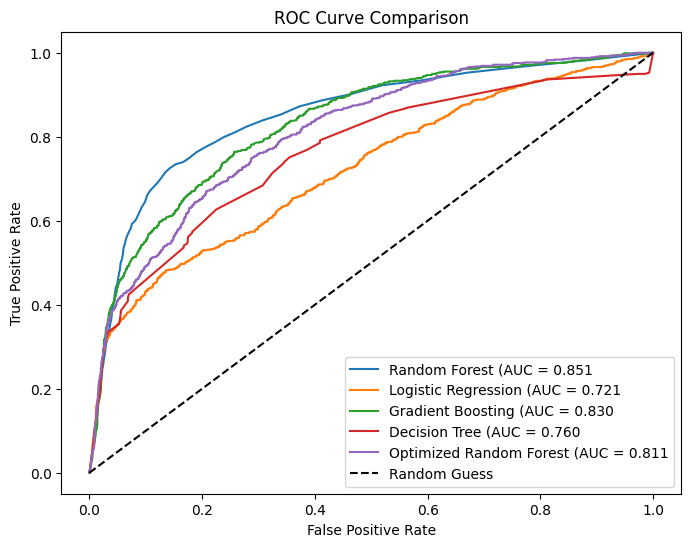

In [582]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(rf_fpr, rf_tpr,
         label=f'Random Forest (AUC = {rf_auc:.3f}')

plt.plot(lr_fpr, lr_tpr,
         label=f'Logistic Regression (AUC = {lr_auc:.3f}')

plt.plot(gb_fpr, gb_tpr,
         label=f'Gradient Boosting (AUC = {gb_auc:.3f}')

plt.plot(dt_fpr, dt_tpr,
         label=f'Decision Tree (AUC = {dt_auc:.3f}')

plt.plot(RF_opt_fpr, RF_opt_tpr,
         label=f'Optimized Random Forest (AUC = {RF_opt_auc:.3f}')



plt.plot([0,1],[0,1],'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')

plt.legend()

plt.show()

### This shows that the RANDOM FOREST MODEL + SMOTE gives a better result becuase it is closer to one and gives the largest Area Under the curve (AUC) therefore our final model will be "THE RANDOM FOREST MODEL + SMOTE"

## Now let's predict the unlabeled data

In [583]:
unlabeled_encoded = pd.get_dummies(
    unlabeled_df,
    drop_first=True
)

In [584]:
unlabeled_encoded = unlabeled_encoded.reindex(
    columns=X.columns,
    fill_value=0
)

In [585]:
print(X_train.columns.tolist())

['Runned_Miles', 'Price', 'Seat_num', 'Door_num', 'issue_id', 'Adv_day', 'repair_complexity', 'repair_cost', 'repair_hours', 'value', 'downtime_days', 'yrs_exist', 'Maker_Bentley', 'Maker_Bugatti', 'Maker_Cadillac', 'Maker_Caterham', 'Maker_Chevrolet', 'Maker_Chrysler', 'Maker_Citroen', 'Maker_Corvette', 'Maker_DS', 'Maker_Dacia', 'Maker_Daewoo', 'Maker_Daihatsu', 'Maker_Daimler', 'Maker_Dodge', 'Maker_Ferrari', 'Maker_Fiat', 'Maker_Ford', 'Maker_GMC', 'Maker_Great Wall', 'Maker_Grinnall', 'Maker_Honda', 'Maker_Hummer', 'Maker_Hyundai', 'Bodytype_Combi Van', 'Bodytype_Convertible', 'Bodytype_Coupe', 'Bodytype_Estate', 'Bodytype_Hatchback', 'Bodytype_MPV', 'Bodytype_Minibus', 'Bodytype_Panel Van', 'Bodytype_Pickup', 'Bodytype_SUV', 'Bodytype_Saloon', 'Bodytype_Tipper', 'Bodytype_Window Van', 'Bodytype_Wood', 'Gearbox_Hybrid', 'Gearbox_Manual', 'Gearbox_Semi-Automatic', 'Fuel_type_Diesel', 'Fuel_type_Electric', 'Fuel_type_Hybrid  Diesel/Electric', 'Fuel_type_Hybrid  Petrol/Electric', 'Fu

In [586]:
print(unlabeled_encoded.columns.tolist())

['Runned_Miles', 'Price', 'Seat_num', 'Door_num', 'issue_id', 'Adv_day', 'repair_complexity', 'repair_cost', 'repair_hours', 'value', 'downtime_days', 'yrs_exist', 'Maker_Bentley', 'Maker_Bugatti', 'Maker_Cadillac', 'Maker_Caterham', 'Maker_Chevrolet', 'Maker_Chrysler', 'Maker_Citroen', 'Maker_Corvette', 'Maker_DS', 'Maker_Dacia', 'Maker_Daewoo', 'Maker_Daihatsu', 'Maker_Daimler', 'Maker_Dodge', 'Maker_Ferrari', 'Maker_Fiat', 'Maker_Ford', 'Maker_GMC', 'Maker_Great Wall', 'Maker_Grinnall', 'Maker_Honda', 'Maker_Hummer', 'Maker_Hyundai', 'Bodytype_Combi Van', 'Bodytype_Convertible', 'Bodytype_Coupe', 'Bodytype_Estate', 'Bodytype_Hatchback', 'Bodytype_MPV', 'Bodytype_Minibus', 'Bodytype_Panel Van', 'Bodytype_Pickup', 'Bodytype_SUV', 'Bodytype_Saloon', 'Bodytype_Tipper', 'Bodytype_Window Van', 'Bodytype_Wood', 'Gearbox_Hybrid', 'Gearbox_Manual', 'Gearbox_Semi-Automatic', 'Fuel_type_Diesel', 'Fuel_type_Electric', 'Fuel_type_Hybrid  Diesel/Electric', 'Fuel_type_Hybrid  Petrol/Electric', 'Fu

In [587]:
missing_cols = set(X_train.columns) - set(unlabeled_encoded.columns)
extra_cols = set(unlabeled_encoded.columns) - set(X_train.columns)

print("Missing:", missing_cols)
print("Extra:", extra_cols)

Missing: set()
Extra: set()


In [588]:
unlabeled_encoded = unlabeled_encoded.reindex(
    columns=X_train.columns,
    fill_value=0
)

In [589]:
predictions = model_smote.predict(unlabeled_encoded)

In [590]:
print(X_train.shape)
print(unlabeled_encoded.shape)

(27036, 77)
(14502, 77)


In [591]:
print(predictions[:10])

[0 0 0 0 0 0 0 0 0 0]


In [592]:
model_prediction_results = {}

In [595]:
unlabeled_df["Label"] = predictions

unlabeled_df.head()
#unlabeled_df.groupby('Label').size()

,Maker,Bodytype,Runned_Miles,Gearbox,Fuel_type,Price,Seat_num,Door_num,issue,issue_id,Adv_day,repair_complexity,repair_cost,repair_hours,value,downtime_days,yrs_exist,Label
0,Ford,SUV,34000,Automatic,Diesel,17290,5,5,Starter Motor Issue,0,15,1,232.9000,3.0,16423.784710,0,3,0
1,Fiat,Hatchback,65000,Manual,Petrol,3980,4,3,Warning Light,0,6,1,219.8000,9.0,3784.524678,2,9,0
2,Fiat,Hatchback,54491,Manual,Petrol,4495,4,3,Flat Tyres,0,24,1,21.3485,1.0,4272.171246,0,6,0
3,Citroen,Hatchback,98000,Manual,still_Diesel_but_you_found_an_easteregg,4795,5,5,Starter Motor Issue,0,12,2,167.9500,6.0,4552.297593,1,7,0
4,Abarth,Hatchback,49583,Automatic,Petrol,11000,4,3,Brake Pads Worn,0,20,2,85.5000,4.0,10447.615700,1,4,0


In [596]:
unlabeled_df.to_csv("C:/Users/Ayobami Adeyemo/Downloads/unlabeled_data_with_predictions.csv", index=False)

In [ ]:
final_sheet = pd.read_csv()

### Step 5: The Baseline Model
Train a standard Random Forest on the imbalanced data.

**Helper** you can save the model results into a dictionary

In [ ]:
model_prediction_results['Baseline RF'] = evaluate_model(rf_baseline, X_val, y_val, "Baseline Random Forest")

NameError: name 'rf_baseline' is not defined

### Step 6: Apply SMOTE
Balance the **training data only** to help the model learn the minority class. Use SMOTE technique for this

### Step 7: Re-evaluate with SMOTE
Let's see how much better Random Forest performs with balanced data.

**Helper** save the model results into a dictionary

In [ ]:
model_prediction_results['SMOTE RF'] = evaluate_model(rf_smote, X_val, y_val, "Random Forest with SMOTE")

### Step 8: The Optimization
Now let us optimize the model.
Find new model for this task.
Apply optimization tecnniques from previous lectures.

### Step 9: Model Comparison
Let's plot the ROC and Precision-Recall curves for all three models togeter. Analythe the results

In [ ]:
plot_comparison_curves(y_val, model_prediction_results)